# Análisis exploratorio - Dataset Ordenes de compras municipales 2024 (Bahia Blanca)

**Materia:** Métodos de Análisis de Datos 1  
**Alumno:** Lucas Calierno  

---

## Objetivo
construir un modelo de regresión para predecir el importe de las órdenes de compra.

---
## Carga de datos

In [804]:
#Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

#Regresion
import statsmodels.api as sm
from statsmodels.formula.api import ols

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error



print("Librerias importadas correctamente")

Librerias importadas correctamente


In [805]:
#Carga de datos
df = pd.read_csv("ordenes_de_compras_municipales-2024.csv")

---

## Exploracion y limpieza de datos

In [806]:
#Lectura de primeras lineas
df.head()


,ejercicio,ordencompra,fecha,importe,proveedor,dependencia,expediente
0,2024,7486,21-10-2024,3.477154e+04,PROMAR S.R. L,DIRECCION GENERAL DE EDUCACION,Suministro 7507/2024
1,2024,7497,22-10-2024,2.815000e+08,SOLUCIONES TURISTICAS SRL.,INSTITUTO DEL DEPORTE,Suministro 5536/2024
2,2024,307,30-01-2024,7.435440e+05,NAVARRETE YAMILA MALENA,SEC. DE OBRAS Y SERVICIOS PUBLICOS,Suministro 393/2024
3,2024,1739,25-03-2024,2.050000e+05,ACQUAMANSA,TEATRO MUNICIPAL,Suministro 2210/2024
4,2024,2991,15-05-2024,1.933479e+05,CODIMAT S.A.,DIRECCION GENERAL DE DISCAPACIDAD Y ACCESIBILIDAD,Suministro 3344/2024


In [807]:
#Muestra de estadisticas descriptivas
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8559 entries, 0 to 8558
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ejercicio    8559 non-null   int64  
 1   ordencompra  8559 non-null   int64  
 2   fecha        8559 non-null   object 
 3   importe      8559 non-null   float64
 4   proveedor    8559 non-null   object 
 5   dependencia  8559 non-null   object 
 6   expediente   8559 non-null   object 
dtypes: float64(1), int64(2), object(4)
memory usage: 468.2+ KB


,ejercicio,ordencompra,importe
count,8559.0,8559.000000,8.559000e+03
mean,2024.0,4444.825797,7.366996e+06
std,0.0,2568.933889,1.102961e+08
min,2024.0,1.000000,4.200000e+02
25%,2024.0,2227.500000,2.190050e+05
50%,2024.0,4434.000000,6.561041e+05
75%,2024.0,6646.500000,1.696600e+06
max,2024.0,9581.000000,5.786833e+09


###  Duplicados

In [808]:
# Eliminar duplicados
df = df.drop_duplicates()
print(f"Dataset después de eliminar duplicados: {df.shape[0]} filas")

Dataset después de eliminar duplicados: 8559 filas


### Inconsistencias

In [809]:
#Conversion y verificacion de la variable fecha
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
df[df['fecha'].isna()]
df[df['fecha'].dt.year != 2024]



,ejercicio,ordencompra,fecha,importe,proveedor,dependencia,expediente


Se verifican fechas mal cargadas desde el origen, y fechas con año distinto de 2024.

In [810]:
#Importes de compra menores a $0
df[df['importe'] <= 0]
df['importe'].quantile([0.99, 0.999])

0.990    7.525111e+07
0.999    9.185693e+08
Name: importe, dtype: float64

Se verifican ordenes de compra con importes menores o iguales a $0, valores muy caros

### Exploracion

In [811]:
#Dependencias con mas ordenes de compra
df['dependencia'].value_counts()

dependencia
DEPARTAMENTO TALLERES Y MAESTRANZA           733
INSTITUTO CULTURAL MUNICIPAL                 667
SEC. DE SALUD                                604
INTENDENCIA                                  563
H.C.D.                                       278
                                            ... 
DEP. PROC. Y COBRO JUD. DE MULTAS IMPAGAS      1
NO USAR-DEPARTAMENTO PLANEAMIENTO URBANO       1
MERCADO MUNICIPAL                              1
DEP. CONTADURIA                                1
NO USAR-DEPARTAMENTO TERRITORIAL               1
Name: count, Length: 149, dtype: int64

In [812]:
#Proveedores con mas ordenes de compra
df['proveedor'].value_counts()

proveedor
LA MOLIENDA                          193
CODIMAT S.A.                         172
AÑOS LUZ                             155
ECOBAHIA S.A.                        102
FERRETERIA CENTRO                     93
                                    ... 
CABODEVILLA MARCELO DAMIAN             1
ZAMORA ROBERTO ADRIAN                  1
MEDINA LEONEL MATIAS                   1
ALBAU INGENIERIA & SERVICIOS SRL.      1
ANDREU MILAGROS FATIMA                 1
Name: count, Length: 1276, dtype: int64

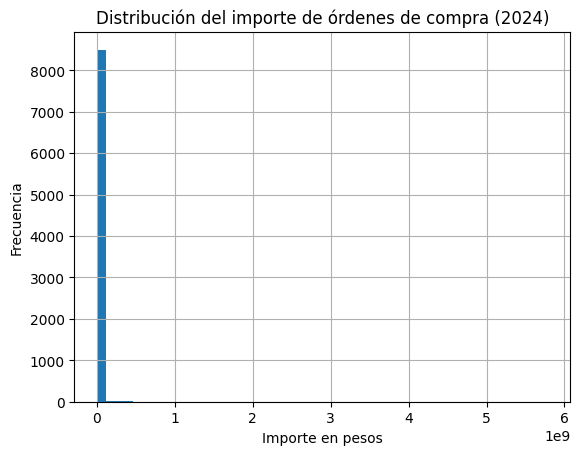

In [813]:
df['importe'].hist(bins=50)

plt.xlabel('Importe en pesos')
plt.ylabel('Frecuencia')
plt.title('Distribución del importe de órdenes de compra (2024)')

plt.show()

En este grafico, se puede ver que el importe de las ordenes de compra en 2024 presenta un fuerte sesgo a la izquierda, lo que sugiere el uso de una variable alternativa para el importe, como podria ser un ajuste logaritmico.

In [814]:
#Analisis de la frecuencia acumulada de las empresas, ordenadas de la de mayor frecuencia absoluta
freq = df['dependencia'].value_counts(normalize=True)
freq_acum = freq.cumsum()

freq_acum.loc[freq_acum.index[:30]]

dependencia
DEPARTAMENTO TALLERES Y MAESTRANZA                   0.085641
INSTITUTO CULTURAL MUNICIPAL                         0.163571
SEC. DE SALUD                                        0.234140
INTENDENCIA                                          0.299918
H.C.D.                                               0.332399
INSTITUTO DEL DEPORTE                                0.361491
SUBSECR. DE NINEZ, ADOLESC. Y FAMILIA                0.389415
DIV. DE CONTROL Y ORDENAMIENTO URBANO                0.414768
DIRECCION GENERAL DE EDUCACION                       0.438369
DEP. PROYECTOS Y OBRAS                               0.460918
SUBSECRETARIA DE AMBIENTE                            0.478561
DEP. MANTENIMIENTO DE ALUMBRADO PUBLICO              0.495385
SEC. DE OBRAS Y SERVICIOS PUBLICOS                   0.512093
SUBSECRETARIA DE PROTECCION CIUDADANA                0.527865
DIVISION DESARROLLO SOCIAL                           0.542937
SUBSECRETARIA RELACIONES INSTITUCIONALES Y CULTO     0.556

---
## Ingenieria de variables

In [815]:
#Creacion de variables auxiliares
#Importe logarimico
df['import_log'] = np.log(df['importe'])

#variables de fecha
df['mes'] = df['fecha'].dt.month
df['dia'] = df['fecha'].dt.day

#Variables categoricas de dependencia, N = 30
top_n = df['dependencia'].value_counts().head(30).index

df['dependencia_grouped'] = df['dependencia'].apply(
    lambda x: x if x in top_n else 'Otras'
)

#Variable binaria de proveedor frecuente con n = 15
df['proveedor_frecuente'] = df['proveedor'].isin(
    freq_prov[freq_prov >= 15].index
).astype(int)

Se crearon variables auxiliares. entre ellas, se encuentran
- import_log: contiene los valores de importes, pero en escala logaritmica, evitando el sesgo a la derecha

- Mes y Dia: Se extrajeron los componentes de la fecha. No se extrajo el año, ya que todos los datos son del 2024

- dependencia_gropued: Se categorizaron las 30 dependencias mas frecuentes, y se acumulo el resto de dependencias en una unica variable categorica denominada 'Otras'. La eleccion del N=30 se basó en que las 30 dependencias mas frecuentes acumulan el 70% del total de las ordenes de compra, por lo que la inclusion de mas categorias no aumenta significativamente el modelado.

- proveedor_frecuente: Se eligió una variable binaria, la cual vale 1 cuando un proveedor tuvo al menos 15 ordenes de compra, y 0 en caso contrario. La eleccion del numero 15 como umbral, se debió a que en distintas pruebas de umbrales, el electo me da una particion balanceada entre proveedores frecuentes y no frecuentes. 

---
## Preguntas bono

In [816]:
ordenes_por_mes = df['mes'].value_counts().sort_index()

print(ordenes_por_mes)

mes_max = ordenes_por_mes.idxmax()

print(f'El mes con más órdenes de compra fue: {mes_max}')

mes
1      362
2      849
3      678
4      738
5     1061
6      641
7      667
8      985
9      853
10     683
11     572
12     470
Name: count, dtype: int64
El mes con más órdenes de compra fue: 5


Creada la variable 'mes', puedo ver la cantidad de ordenes de compra por mes, permitiendo responder la pregunta bono 1

In [817]:
gasto_dependencia = df.groupby('dependencia')['importe'].sum()

print(gasto_dependencia.sort_values(ascending=False).head())

dependencia_max = gasto_dependencia.idxmax()

print(f'La dependencia con mayor gasto acumulado fue: {dependencia_max}, con un gasto de {gasto_dependencia.max():,.2f}')

dependencia
SUBSECRETARIA DE AMBIENTE                2.084543e+10
DEP. PROYECTOS Y OBRAS                   5.908784e+09
DEP. VIALIDAD                            5.106130e+09
SUBSECRETARIA DE PROTECCION CIUDADANA    4.803266e+09
DEPARTAMENTO TALLERES Y MAESTRANZA       3.102099e+09
Name: importe, dtype: float64
La dependencia con mayor gasto acumulado fue: SUBSECRETARIA DE AMBIENTE, con un gasto de 20,845,432,349.69


Este analisis me permite ver el monto gastado por las dependencias, ordenado de mayor a menor, lo que me permite responder la pregunta bono 2

In [818]:
#Proveedores con mas ordenes de compra
df['proveedor'].value_counts()

proveedor
LA MOLIENDA                          193
CODIMAT S.A.                         172
AÑOS LUZ                             155
ECOBAHIA S.A.                        102
FERRETERIA CENTRO                     93
                                    ... 
CABODEVILLA MARCELO DAMIAN             1
ZAMORA ROBERTO ADRIAN                  1
MEDINA LEONEL MATIAS                   1
ALBAU INGENIERIA & SERVICIOS SRL.      1
ANDREU MILAGROS FATIMA                 1
Name: count, Length: 1276, dtype: int64

Analisis de los provedores con mayor cantidad de ordenes de compra, dando respuesta a la pregunta bono 3

---
## Modelado

In [819]:
features = pd.DataFrame({
    'importe': df['import_log'],
    'mes': df['mes'],
    'dia': df['dia'],
    'proveedor_frec': df['proveedor_frecuente'],
    'dependencia': df['dependencia_grouped']
})

La variable objetivo fue el logaritmo natural del importe de cada orden de compra, debido a que la distribución original del importe presentaba una fuerte sesgo hacia la izquierda. La transformación logarítmica permitió estabilizar la varianza y obtener un comportamiento más cercano a los supuestos del modelo lineal.

Como variables explicativas se incluyeron:

* el mes de emisión de la orden,
* el día de la semana de emision de la orden,
* una variable binaria indicando si el proveedor es frecuente,
* la dependencia municipal responsable de la compra.

La variable 'dependencia' fue agrupada conservando únicamente las categorías más frecuentes y reuniendo el resto en “Otras”, con el objetivo de reducir la cardinalidad y mejorar el modelado

In [820]:
modelo_multiple = ols('importe ~ mes + dia + proveedor_frec + dependencia', 
                      data=features).fit()

print(modelo_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:                importe   R-squared:                       0.170
Model:                            OLS   Adj. R-squared:                  0.167
Method:                 Least Squares   F-statistic:                     53.08
Date:                Sun, 10 May 2026   Prob (F-statistic):          5.18e-315
Time:                        20:54:58   Log-Likelihood:                -15847.
No. Observations:                8559   AIC:                         3.176e+04
Df Residuals:                    8525   BIC:                         3.200e+04
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
                                                                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

---
## Diagnostico

In [821]:
#Division en train - test
train_df, test_df = train_test_split(
    features,
    test_size=0.2,
    random_state=42
)

In [822]:
#Fase train
modelo = ols(
    'importe ~ mes + dia + proveedor_frec + dependencia',
    data=train_df
).fit()

In [823]:
#Modelo de prediccion
pred = modelo.predict(test_df)

In [824]:
#Calculo del R^2
r2_test = r2_score(test_df['importe'], pred)
print('R^2: ', r2_test)

#Calculo del RMSE
rmse = np.sqrt(mean_squared_error(test_df['importe'], pred))
print('RSME: ', rmse)

R^2:  0.15488267983044313
RSME:  1.5699361728025307


El modelo obtuvo un R^2  de aproximadamente 0.15, indicando que logra explicar cerca del 17% de la variabilidad observada en el logaritmo del importe. Si bien es un R^2 bajo, no necesariamente significa que el modelado sea incorrecto, sino que hay variables explicativas no consideradas en el modelado, como podrian ser el producto adquirido, las cantidades, el contexto economico, entre otras

El RMSE calculado sobre el conjunto de validación refleja el error promedio de predicción del modelo sobre observaciones no utilizadas durante el entrenamiento. El valor obtenido indica que, si bien el modelo logra capturar ciertas tendencias generales, persiste una dispersión considerable en los importes reales respecto de los valores predichos.

In [825]:
residuos = test_df['importe'] - pred

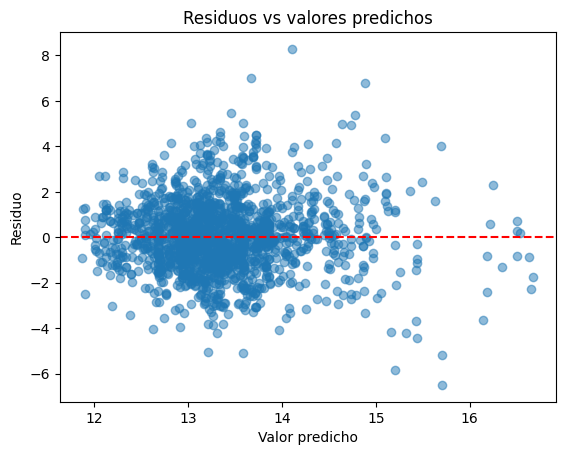

In [826]:
plt.scatter(pred, residuos, alpha=0.5)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel('Valor predicho')
plt.ylabel('Residuo')
plt.title('Residuos vs valores predichos')

plt.show()

El análisis de residuos muestra una mayor concentracion en valores cercanos al 0. Sin embargo, la presencia de residuos muy altos, sugiere nuevamente que hay factores relevantes que no fueron incluidos en el modelado

---
## Interpretacion

Las variables con mayor influencia sobre el importe fueron las asociadas a la dependencia municipal responsable de la orden de compra. En particular, areas como Vialidad, Proyectos y Obras, y Mantenimiento de Alumbrado Público, presentaron los coeficientes positivos mas elevados, indicando una tendencia a generar órdenes de compra de montos considerablemente mayores. Esto lleva a la conclusion de que se realizaron grandes proyectos de obra publica y mantenimiento de infraestructura. 

En cambio, las variables temporales como el dia de la semana o el mes, presentaron menor influencia, por lo que no influyeron mucho en el modelado.